In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = pd.read_csv("fashion-mnist_train.csv")
test = pd.read_csv("fashion-mnist_test.csv")



In [21]:
train.shape

(60000, 785)

In [22]:
test.shape

(10000, 785)

In [23]:
x_train = train.drop("label", axis=1)
y_train = train["label"]
x_train = x_train/255.0

x_train = x_train.values
y_train = y_train.values

x_test = test.drop('label', axis=1)
y_test = test["label"]

x_test = x_test/255.0
x_test = x_test.values
y_test = y_test.values



In [24]:
class customDataset(Dataset):
    def __init__(self,x,y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return self.x.shape[0]
    
    def __getitem__(self,index):
        return self.x[index], self.y[index]
    

train_dataset = customDataset(x_train,y_train)
test_dataset =  customDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=torch.cuda.is_available())



In [25]:
class fashion_nn(nn.Module):
    def __init__(self, n_features = 784, n_labels = 10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_features, 372),
            nn.ReLU(),
            nn.Linear(372,180),
            nn.ReLU(),
            nn.Linear(180,90),
            nn.ReLU(),
            nn.Linear(90,45),
            nn.ReLU(),
            nn.Linear(45,22),
            nn.ReLU(),
            nn.Linear(22,10)

        )

    def forward(self,x):
        return self.model(x)
        

model = fashion_nn(x_train.shape[1],10)
model = model.to(device)
model


fashion_nn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=372, bias=True)
    (1): ReLU()
    (2): Linear(in_features=372, out_features=180, bias=True)
    (3): ReLU()
    (4): Linear(in_features=180, out_features=90, bias=True)
    (5): ReLU()
    (6): Linear(in_features=90, out_features=45, bias=True)
    (7): ReLU()
    (8): Linear(in_features=45, out_features=22, bias=True)
    (9): ReLU()
    (10): Linear(in_features=22, out_features=10, bias=True)
  )
)

In [26]:
epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr =0.0001)

Epoch : [1 / 5] : 1.0599472881
Epoch : [2 / 5] : 0.6119618288
Epoch : [3 / 5] : 0.5233336662
Epoch : [4 / 5] : 0.4812186794
Epoch : [5 / 5] : 0.4502735297


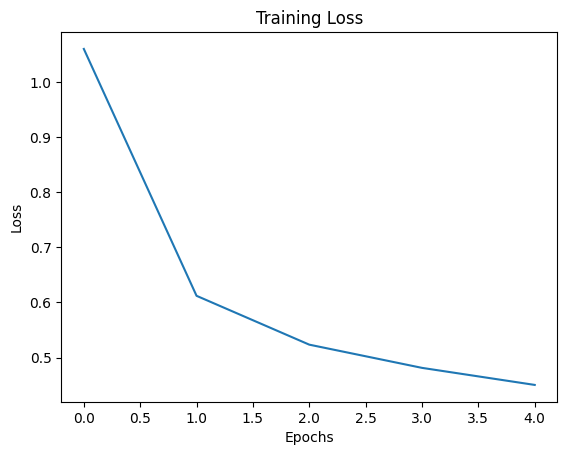

In [27]:
train_loss = []
for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0
    
    for batch_x,batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        y_pred = model(batch_x)
        loss = loss_fn(y_pred,batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss+= loss.item()
    average_epoch_loss = total_epoch_loss/len(train_loader)
    train_loss.append(average_epoch_loss)
    print(f"Epoch : [{epoch + 1 } / {epochs}] : {average_epoch_loss:.10f}")
plt.plot([t1 for t1 in train_loss])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()



In [28]:
total_labels = len(test_dataset)
correct = 0
model.eval()

with torch.no_grad():
    for batch_x,batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        y_preds = model(batch_x)
        predicted_labl = torch.argmax(y_preds,dim =1)

        batch_correct_preds = (predicted_labl == batch_y).sum().item()
        correct += batch_correct_preds

acc = correct/ total_labels
print(f"The accuracy of the currrent model is : {acc*100:.10f}")

The accuracy of the currrent model is : 84.2300000000
